# Simple Grid World: Policy Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [196]:
import numpy as np
np.set_printoptions(precision=2)

In [197]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the L-Maze Grid World 

In [198]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

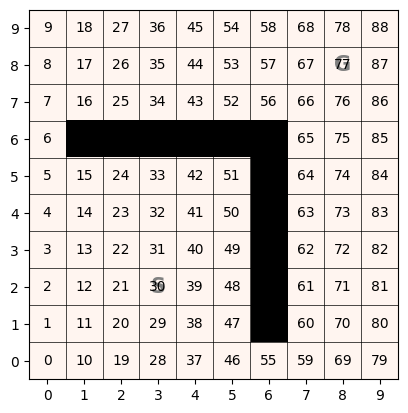

In [199]:
env.image()

## Policy Approximation: Linear Soft-Max In Action Preferences

Use Fourier-basis transformation and set up state-action features.

In [200]:
from gym_classics.algorithms.linear_approximation import transformation_fourier_basis, active_weights

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

def state_features(s,env):
    return trans_fb(env.decode(s))

In [201]:
def state_action_features(s,a,env):
    s = state_features(s,env)
    features = np.zeros(1+len(s)*env.action_space.n)
    features[active_weights(a, len(s)-1)] = s
    return features

Define the preference function and the soft-max policy based on the preferences.

In [202]:
def h(s,a,theta,env):
    x = np.zeros_like(theta)
    s = state_features(s,env)
    x[active_weights(a, len(s)-1)] = s
    
    return np.dot(theta, x)

In [203]:
def pi(s,theta,env):
    hs = np.array([h(s,a,theta,env) for a in range(env.action_space.n)])
    exp_hs = np.exp(hs - np.max(hs))
    return exp_hs / np.sum(exp_hs)

Check with a random weight vector.

In [204]:
theta = np.random.rand(1+len(state_features(0, env))*env.action_space.n)
theta

array([0.79, 0.08, 0.97, 0.65, 0.06, 0.65, 0.06, 0.61, 0.47, 0.6 , 0.75,
       0.07, 0.55, 0.6 , 0.26, 0.44, 0.67, 0.72, 0.34, 0.26, 0.15, 0.01,
       0.57, 0.24, 0.79, 0.82, 0.01, 0.15, 0.62, 0.04, 0.44, 0.14, 0.33,
       0.02, 0.05, 0.95, 0.21])

Calculate the preferences score for all actions for state 0.

In [205]:
[h(0,a,theta, env) for a in range(env.action_space.n)] 

[np.float64(4.334566155149137),
 np.float64(4.7412624091632996),
 np.float64(3.878589954201839),
 np.float64(3.3451450062368395)]

Calculate $\pi(s,a,\theta)$ for all actions in state $s=0$

In [206]:
pi(0,theta,env)

array([0.29, 0.43, 0.18, 0.11])

## REINFORCE

![Pseudocode REINFORCE](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_REINFORCE.png)

We need to sample following a stochastic policy.

In [207]:
def sample_episode_policy(env, pi, theta, max_episode_length=1000):
    """
    Sample an episode using the policy defined by pi and theta.
    Returns a list of (state, action, reward) tuples.
    """
    s, _ = env.reset()
    episode_data = []
    
    for t in range(max_episode_length):
        a = np.random.choice(range(env.action_space.n), p=pi(s,theta,env))
        next_s, r, done, _, _ = env.step(a)
        episode_data.append((s, a, r, next_s))
        s = next_s
        
        if done:
            break
    
    return episode_data


In [208]:
episode_data = sample_episode_policy(env, pi, theta)
episode_data

[(30, np.int64(2), 0.0, 29),
 (29, np.int64(1), 0.0, 38),
 (38, np.int64(3), 0.0, 29),
 (29, np.int64(1), 0.0, 38),
 (38, np.int64(1), 0.0, 47),
 (47, np.int64(1), 0.0, 47),
 (47, np.int64(2), 0.0, 46),
 (46, np.int64(2), 0.0, 46),
 (46, np.int64(0), 0.0, 47),
 (47, np.int64(1), 0.0, 47),
 (47, np.int64(0), 0.0, 48),
 (48, np.int64(3), 0.0, 39),
 (39, np.int64(3), 0.0, 30),
 (30, np.int64(0), 0.0, 31),
 (31, np.int64(2), 0.0, 30),
 (30, np.int64(2), 0.0, 29),
 (29, np.int64(1), 0.0, 38),
 (38, np.int64(0), 0.0, 39),
 (39, np.int64(0), 0.0, 40),
 (40, np.int64(2), 0.0, 39),
 (39, np.int64(0), 0.0, 40),
 (40, np.int64(3), 0.0, 31),
 (31, np.int64(2), 0.0, 30),
 (30, np.int64(3), 0.0, 21),
 (21, np.int64(2), 0.0, 20),
 (20, np.int64(0), 0.0, 21),
 (21, np.int64(3), 0.0, 12),
 (12, np.int64(1), 0.0, 21),
 (21, np.int64(3), 0.0, 12),
 (12, np.int64(0), 0.0, 13),
 (13, np.int64(0), 0.0, 14),
 (14, np.int64(2), 0.0, 13),
 (13, np.int64(0), 0.0, 14),
 (14, np.int64(0), 0.0, 15),
 (15, np.int64

Implement the REINFORCE algorithm. The gradient of the policy for linear approximation is proportional to  $\nabla ln \pi(s,a,\bf{\theta}) =   \bf{x}(s,a) - \sum_b \pi(b|s,\bf{\theta}) \bf{x}(s,b)$

In [ ]:
from tqdm import tqdm

def REINFORCE(
    env,
    n,
    alpha,
    gamma,
    theta = None,
    max_episode_length=1000,
    verbose=False
    ):
    
    if theta is None:
        theta = np.zeros(1+len(state_features(0, env))*env.action_space.n)
        
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        if verbose:
            print(f"Episode {episode+1}/{n}")
        
        episode_data = sample_episode_policy(env, pi, theta, max_episode_length)
        
        for t in range(len(episode_data)):
            #print(episode_data[t])
        
            G = np.sum([e[2] for e in episode_data[t:]] * (gamma ** np.arange(len(episode_data[t:]))))

            s,a,r,next_s = episode_data[t]
            
            # ln policy gradient= x(s,a)- sum_b pi(b|s,theta) x(s,b)
            grad_log_pi = state_action_features(s, a, env) - sum([pi(s, theta, env)[b] * state_action_features(s, b, env) for b in range(env.action_space.n)])
            
            if verbose: 
                print (f"t: {t}, G: {G:.2f}, grad_log_pi: {grad_log_pi}")
            
            theta += alpha * (gamma**t) * G * grad_log_pi      
    return theta

In [210]:
theta = REINFORCE(env, n=500, alpha=0.1, gamma=0.99)
theta

Episodes: 100%|██████████| 500/500 [00:04<00:00, 114.77it/s]


array([ 7.99e-15, -1.69e-02, -1.54e+00,  1.30e+00,  5.55e-01,  9.45e-01,
        2.86e+00,  2.45e+00, -1.95e-01, -1.06e+00,  8.73e-01, -1.10e-01,
       -1.29e+00,  2.87e+00, -6.66e-01,  9.55e-01,  5.46e-01, -7.40e-01,
        1.58e+00, -1.04e+00,  1.19e+00, -1.73e+00, -7.40e-01,  5.12e-02,
        7.84e-01,  1.81e+00, -9.12e-01, -1.50e-01, -4.61e-01, -2.09e+00,
       -1.45e+00, -3.45e+00, -1.13e+00,  0.00e+00,  0.00e+00,  0.00e+00,
        0.00e+00])

## The Learned Policy

In [ ]:
pol = [pi(s, theta,env) for s in range(env.observation_space.n)]
pol

[array([9.85e-01, 1.45e-02, 9.18e-04, 6.83e-07]),
 array([9.92e-01, 6.87e-03, 7.95e-04, 1.67e-06]),
 array([9.98e-01, 1.01e-03, 5.56e-04, 1.84e-05]),
 array([9.99e-01, 1.15e-04, 3.98e-04, 4.48e-04]),
 array([9.90e-01, 3.03e-05, 3.84e-04, 9.73e-03]),
 array([9.17e-01, 4.10e-05, 5.83e-04, 8.21e-02]),
 array([8.13e-01, 3.71e-04, 1.46e-03, 1.85e-01]),
 array([0.83, 0.02, 0.01, 0.15]),
 array([0.44, 0.52, 0.01, 0.03]),
 array([3.40e-02, 9.62e-01, 3.04e-03, 9.06e-04]),
 array([9.63e-01, 3.43e-02, 2.90e-03, 7.34e-06]),
 array([9.81e-01, 1.44e-02, 4.23e-03, 1.24e-04]),
 array([0.99, 0.  , 0.  , 0.  ]),
 array([8.49e-01, 3.32e-04, 3.33e-03, 1.47e-01]),
 array([3.01e-01, 5.67e-05, 1.14e-03, 6.98e-01]),
 array([1.26e-01, 6.38e-05, 6.35e-04, 8.73e-01]),
 array([0.43, 0.13, 0.01, 0.43]),
 array([0.08, 0.9 , 0.01, 0.01]),
 array([1.00e-02, 9.88e-01, 1.60e-03, 3.73e-04]),
 array([0.7 , 0.25, 0.05, 0.  ]),
 array([0.66, 0.09, 0.1 , 0.15]),
 array([0.08, 0.  , 0.02, 0.9 ]),
 array([5.27e-03, 3.52e-05, 

Visualize the learned policy by showing the action with the highest probability. The probability is shown using the tile color. 
Closer to 1 means that the algorithm is more sure about the action. Smaller values means that the algorithms still would like to explore.

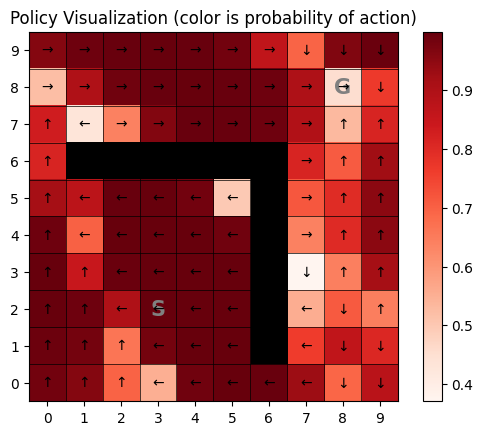

In [212]:
pol_discrete = np.argmax(pol, axis=1)
prob = np.max(pol, axis=1)
env.image(V=prob, policy=pol_discrete, title="Policy Visualization (color is probability of action)")

Visualize the found path using the highest probability action.

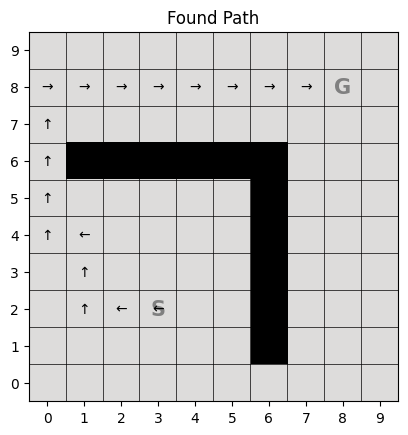

In [214]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_discrete, max_len=100)
env.image(policy=pol_discrete, episode=path, title='Found Path', clim=(-1,1))


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)